   5.1  3.5  1.4  0.2  Iris-setosa
0  4.9  3.0  1.4  0.2  Iris-setosa
1  4.7  3.2  1.3  0.2  Iris-setosa
2  4.6  3.1  1.5  0.2  Iris-setosa
3  5.0  3.6  1.4  0.2  Iris-setosa
4  5.4  3.9  1.7  0.4  Iris-setosa


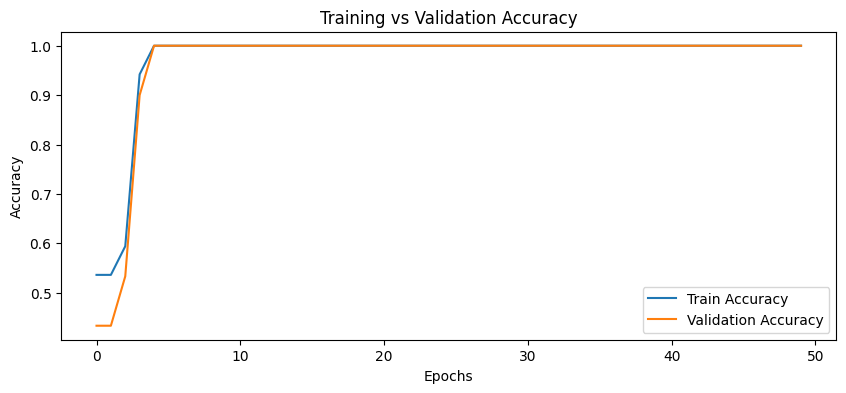

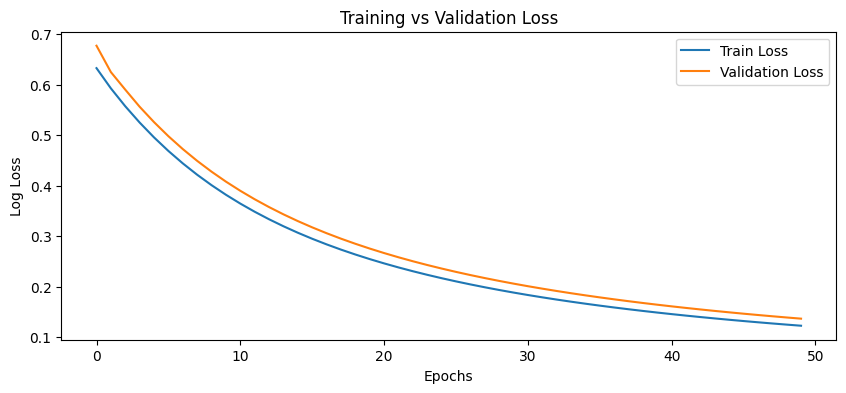

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss

df = pd.read_excel("PMM-TemplateSLP.xlsx", sheet_name="Data")
print(df.head())

X = df.iloc[:, 0:4].values
y = df.iloc[:, 4].values
y = np.where(y == "Iris-setosa", 0, 1)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def train_slp(X, y, lr=0.1, epochs=50):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    bias = 0.0

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        linear_output = np.dot(X, weights) + bias
        y_pred = sigmoid(linear_output)

        error = y_pred - y
        dw = np.dot(X.T, error) / n_samples
        db = np.sum(error) / n_samples

        weights -= lr * dw
        bias -= lr * db

        y_train_pred = sigmoid(np.dot(X_train, weights) + bias)
        y_val_pred = sigmoid(np.dot(X_val, weights) + bias)

        train_loss = log_loss(y_train, y_train_pred)
        val_loss = log_loss(y_val, y_val_pred)

        train_acc = accuracy_score(y_train, y_train_pred.round())
        val_acc = accuracy_score(y_val, y_val_pred.round())

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

    return weights, bias, train_losses, val_losses, train_accs, val_accs

weights, bias, train_losses, val_losses, train_accs, val_accs = train_slp(X_train, y_train, lr=0.1, epochs=50)

plt.figure(figsize=(10,4))
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Log Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()
